# **Hospital Readmission Analysis**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data_path = '/content/drive/My Drive/Copy of hospital_readmissions.csv'
df = pd.read_csv(data_path)

In [5]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


**Missing values check**

In [6]:
df.isna().sum()

,0
age,0
time_in_hospital,0
n_lab_procedures,0
n_procedures,0
n_medications,0
n_outpatient,0
n_inpatient,0
n_emergency,0
medical_specialty,0
diag_1,0


In [7]:
missing_counts = (df == 'Missing').sum()
print(missing_counts)

age                      0
time_in_hospital         0
n_lab_procedures         0
n_procedures             0
n_medications            0
n_outpatient             0
n_inpatient              0
n_emergency              0
medical_specialty    12382
diag_1                   4
diag_2                  42
diag_3                 196
glucose_test             0
A1Ctest                  0
change                   0
diabetes_med             0
readmitted               0
dtype: int64


In [8]:
df['medical_specialty'] = df['medical_specialty'].replace('Missing', 'Unknown')

In [9]:
df['diag_1'] = df['diag_1'].replace('Missing', 'other')
df['diag_2'] = df['diag_2'].replace('Missing', 'other')
df['diag_3'] = df['diag_3'].replace('Missing', 'other')

In [10]:
missing_counts = (df == 'Missing').sum()
print(missing_counts)

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64


**The Association Between Medical Burden and Readmission**

In [11]:
df['readmitted_binary'] = df['readmitted'].map({'yes': 1, 'no': 0})

In [12]:
metrics = ['time_in_hospital', 'n_lab_procedures', 'n_medications']

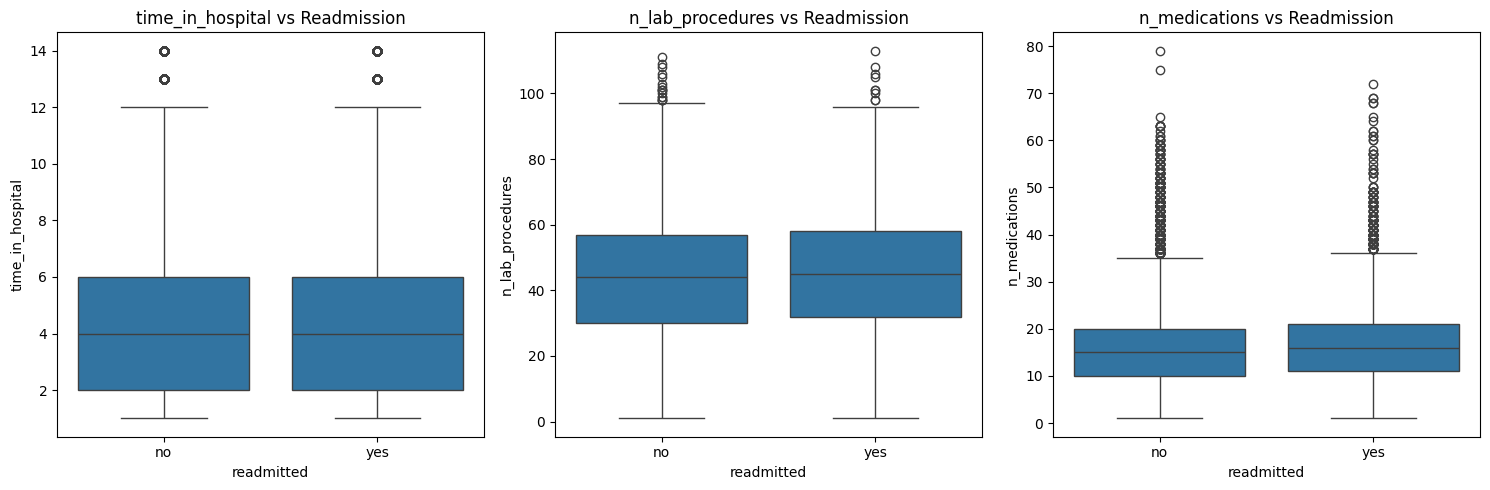

In [13]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(metrics):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x='readmitted', y=col)
    plt.title(f'{col} vs Readmission')

plt.tight_layout()
plt.show()

In [14]:
correlation_matrix = df[['readmitted_binary', 'time_in_hospital', 'n_lab_procedures', 'n_medications']].corr()
print("Correlation Matrix：")
print(correlation_matrix['readmitted_binary'])

Correlation Matrix：
readmitted_binary    1.000000
time_in_hospital     0.043141
n_lab_procedures     0.032970
n_medications        0.036871
Name: readmitted_binary, dtype: float64


In [15]:
age_readmission = df.groupby('age')['readmitted_binary'].mean().sort_values(ascending=False)
print("Readmission rates by age group：\n", age_readmission)

Readmission rates by age group：
 age
[80-90)     0.495793
[70-80)     0.487933
[60-70)     0.468459
[40-50)     0.445103
[50-60)     0.441599
[90-100)    0.421333
Name: readmitted_binary, dtype: float64


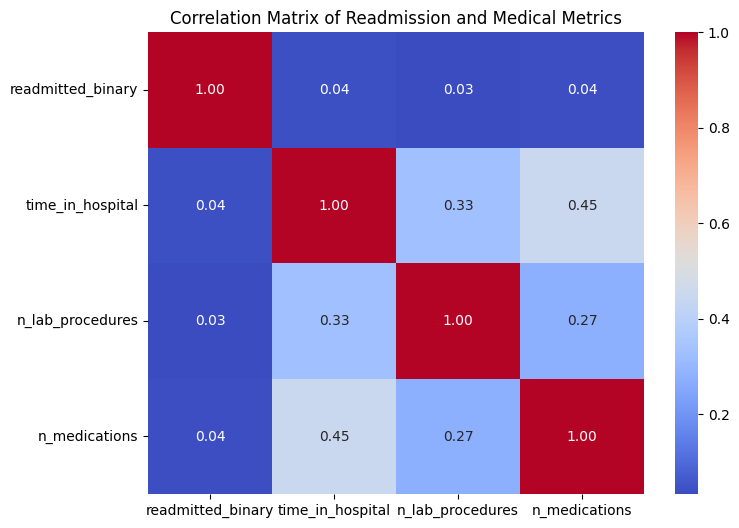

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Readmission and Medical Metrics')
plt.show()

**Analyzing the Impact of Different Diagnostic Outcomes on Re-enrollment Rates**

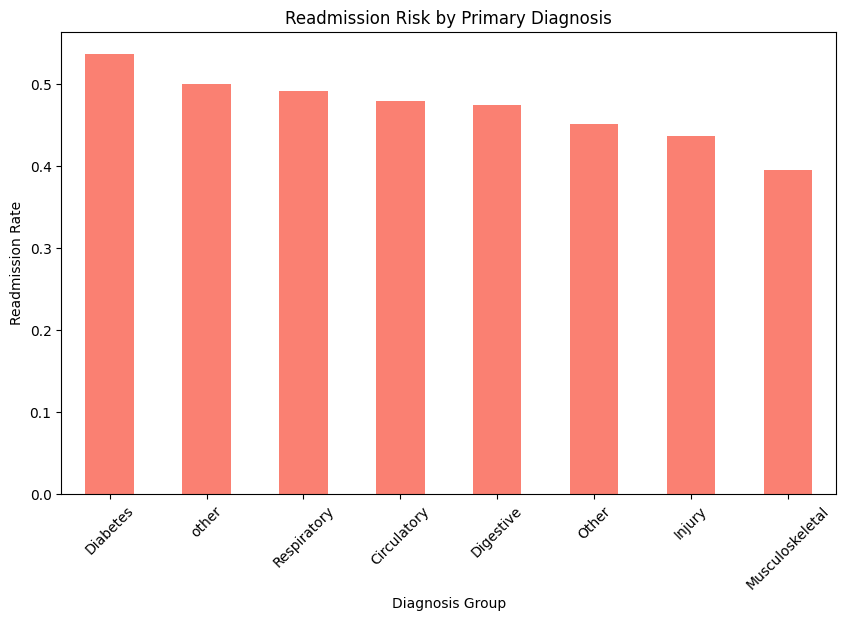

In [17]:
diag_risk = df.groupby('diag_1')['readmitted'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
diag_risk.plot(kind='bar', color='salmon')
plt.title('Readmission Risk by Primary Diagnosis')
plt.ylabel('Readmission Rate')
plt.xlabel('Diagnosis Group')
plt.xticks(rotation=45)
plt.show()

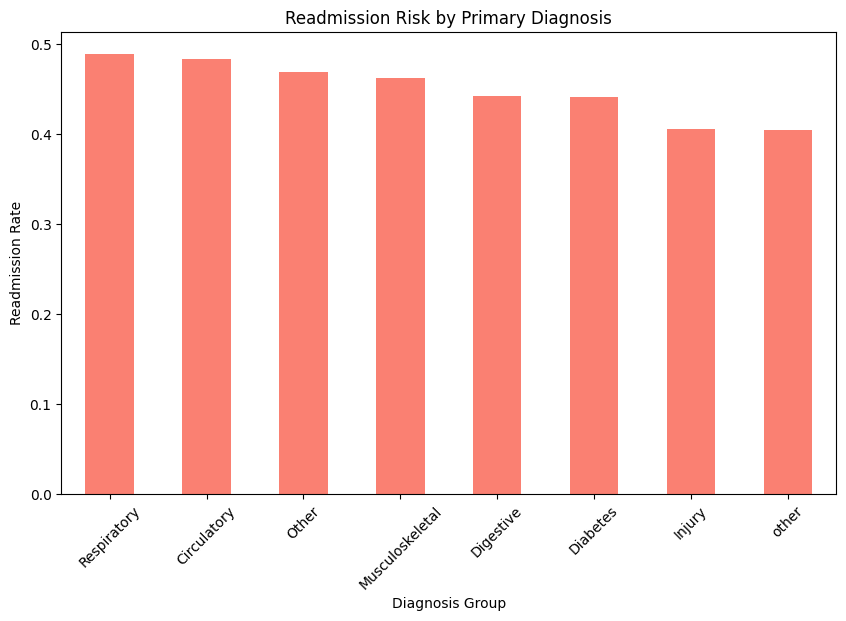

In [18]:
diag_risk = df.groupby('diag_2')['readmitted'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
diag_risk.plot(kind='bar', color='salmon')
plt.title('Readmission Risk by Primary Diagnosis')
plt.ylabel('Readmission Rate')
plt.xlabel('Diagnosis Group')
plt.xticks(rotation=45)
plt.show()

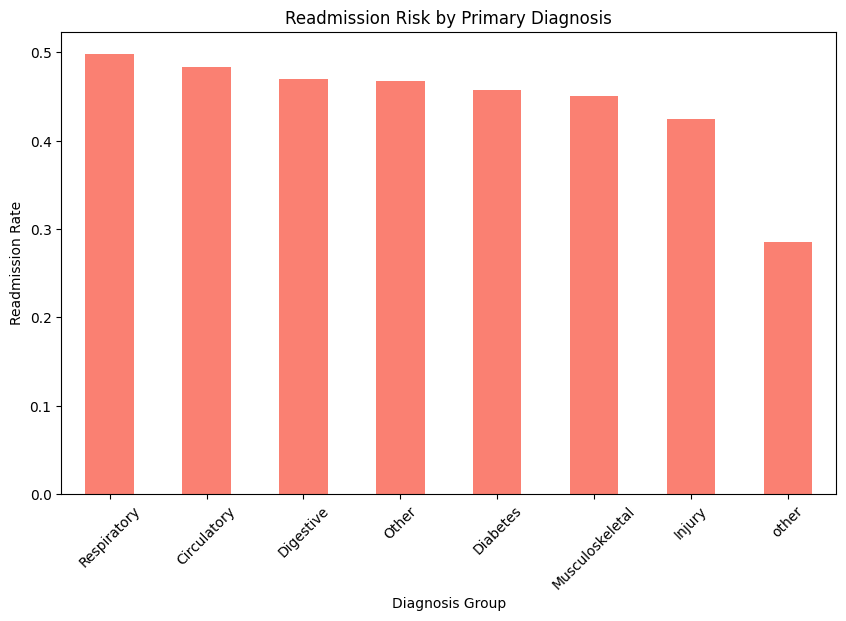

In [19]:
diag_risk = df.groupby('diag_3')['readmitted'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
diag_risk.plot(kind='bar', color='salmon')
plt.title('Readmission Risk by Primary Diagnosis')
plt.ylabel('Readmission Rate')
plt.xlabel('Diagnosis Group')
plt.xticks(rotation=45)
plt.show()

**MNAR analysis**

In [36]:
df['readmitted_binary'] = df['readmitted'].map({'yes': 1, 'no': 0})

# Re-apply the replacement to ensure 'Unknown' values are present
df['medical_specialty'] = df['medical_specialty'].replace('Missing', 'Unknown')
df['is_specialty_unknown'] = (df['medical_specialty'] == 'Unknown').astype(int)

analysis = df.groupby('is_specialty_unknown')['readmitted_binary'].mean()
print(f"readmitted of known group: {analysis[0]:.2%}")
print(f"readmitted of unkown group: {analysis[1]:.2%}")

# Chi-Square Test
contingency_table = pd.crosstab(df['is_specialty_unknown'], df['readmitted'])
chi2, p, dof, ex = stats.chi2_contingency(contingency_table)

print(f"\nChi-Square Test P-value: {p:.4e}")
if p < 0.05:
    print("conclusion：Unknown status is significantly associated with readmission, and the missing data are not random.")

readmitted of known group: 45.16%
readmitted of unkown group: 48.91%

Chi-Square Test P-value: 3.0278e-09
conclusion：Unknown status is significantly associated with readmission, and the missing data are not random.


**T-test and Cohen's d**

In [35]:
from scipy.stats import ttest_ind
import numpy as np

readmitted_yes = df[df['readmitted'] == 'yes']['time_in_hospital']
readmitted_no = df[df['readmitted'] == 'no']['time_in_hospital']

t_stat, p_val = ttest_ind(readmitted_yes, readmitted_no)

def cohen_d(x, y):
    return (np.mean(x) - np.mean(y)) / np.sqrt((np.std(x, ddof=1)**2 + np.std(y, ddof=1)**2) / 2)

d = cohen_d(readmitted_yes, readmitted_no)

print(f"t-stat p value: {p_val:.4e}")
print(f"Cohen's d: {d:.4f}")

t-stat p value: 8.8487e-12
Cohen's d: 0.0865
